# Прогнозирование цены

### Задача
Целевая переменная — `price`. У вас есть 4 атрибута, и, очевидно, мы хотим, чтобы вы построили некую модель машинного обучения, которая прогнозирует цены.

1. Проведите первоначальный анализ данных.
2. Используйте ML модель и кратко объясните свой выбор.
3. Покажите точность вашей модели и прокомментируйте результаты.
4. Представьте нам результаты и шаги, которые вы предприняли, а также некоторые критические размышления.
5. Визуализируйте на графиках точность модели, важность признаков и корреляцию признаков с ценой.  

### Описание данных
Данные представлены в файле `44_price_sample.csv`.

### Комментарии

Определите, обучите и оцените прогнозирующую модель, которая принимает в качестве входных данных предоставленные данные. По вашему усмотрению вы можете разделить данные на наборы для обучения, тестирования. 

Убедитесь, что решение отражает весь ваш мыслительный процесс (для каждой ячейки кода оставляйте комментарии, иначе мы не поймем, что вы хотели сделать)

### Что мы точно хотим увидеть в вашей работе?

1. **Анализ данных**: Проведение первичного анализа данных для понимания их структуры и основных характеристик. 

2. **Обработка данных**: Это критически важный шаг, который включает в себя очистку данных, обработку пропущенных значений и дубликатов.

3. **Оценка модели**: Обучение и тестирование подходящей модели и оценка ее производительности с использованием релевантных метрик.

4. **Визуализация**: Постройте графики, которые покажут точность модели, важность признаков и корреляцию признаков с ценой. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Загрузка данных
df = pd.read_csv("44_price_sample.csv")

In [3]:
# Просмотр первых строк
df.head()

,para1,para2,para3,para4,price
0,1,662.0,3000.0,3.8,73.49
1,1,340.0,2760.0,9.2,300.00
2,0,16.0,2700.0,3.0,130.00
3,1,17.0,12320.0,6.4,365.00
4,1,610.0,2117.0,10.8,357.50


In [4]:
# Информация о столбцах
print("\nИнформация о данных:")
df.info()


Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   para1   10003 non-null  int64  
 1   para2   9997 non-null   float64
 2   para3   10003 non-null  float64
 3   para4   9998 non-null   float64
 4   price   10003 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 390.9 KB


In [5]:
# Статистическое описание
print("\nСтатистика:")
df.describe()


Статистика:


,para1,para2,para3,para4,price
count,10003.000000,9997.000000,10003.000000,9998.000000,10003.000000
mean,1.380986,447.270681,9547.975527,8.458024,433.774924
std,3.500408,220.913801,8022.286943,4.613645,277.443154
min,0.000000,16.000000,200.000000,1.000000,50.730000
25%,1.000000,301.000000,2899.500000,4.000000,250.000000
50%,1.000000,434.000000,6446.000000,7.200000,370.000000
75%,1.000000,582.000000,15000.000000,13.600000,550.000000
max,337.000000,2554.000000,34782.000000,27.200000,5700.000000


In [6]:
# Проверка на пропущенные значения
print("\nПропущенные значения:")
print(df.isnull().sum())

# Если есть пропуски, можно удалить или заполнить средним:
# df = df.dropna()
# или
# df = df.fillna(df.mean(numeric_only=True))


Пропущенные значения:
para1    0
para2    6
para3    0
para4    5
price    0
dtype: int64


In [7]:
# Заполним пропуски средним:
df = df.fillna(df.mean(numeric_only=True))

In [9]:
print("\nПропущенные значения:")
print(df.isnull().sum())


Пропущенные значения:
para1    0
para2    0
para3    0
para4    0
price    0
dtype: int64


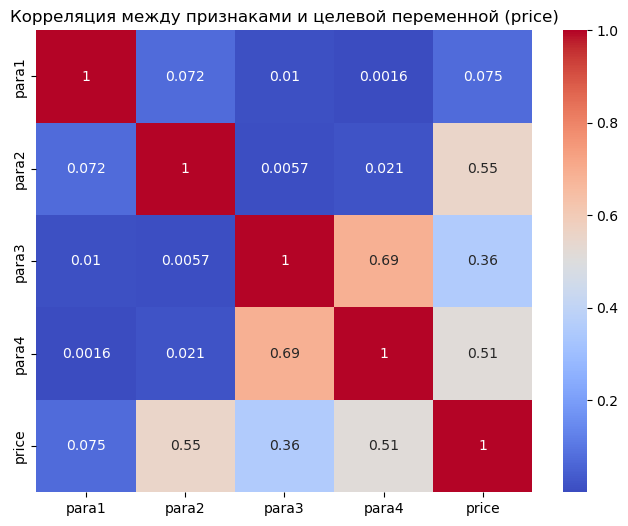

In [10]:
# Корреляционная матрица
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Корреляция между признаками и целевой переменной (price)")
plt.show()

In [11]:
# Целевая переменная
y = df['price']

# Признаки
X = df.drop('price', axis=1)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Создание модели
model = LinearRegression()

# Обучение модели
model.fit(X_train, y_train)

LinearRegression()

In [13]:
# Предсказания на тестовой выборке
y_pred = model.predict(X_test)

# Метрики
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nСреднеквадратичная ошибка (MSE): {mse:.2f}")
print(f"Коэффициент детерминации (R²): {r2:.2f}")


Среднеквадратичная ошибка (MSE): 39723.15
Коэффициент детерминации (R²): 0.55


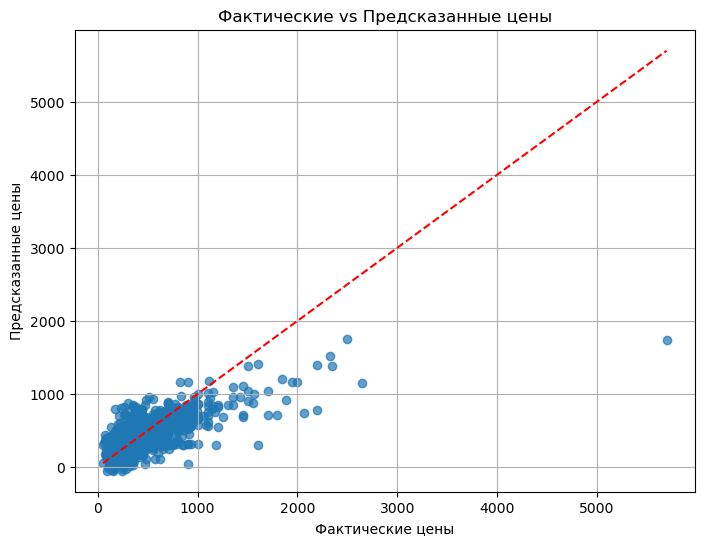

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Фактические цены")
plt.ylabel("Предсказанные цены")
plt.title("Фактические vs Предсказанные цены")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.grid(True)
plt.show()

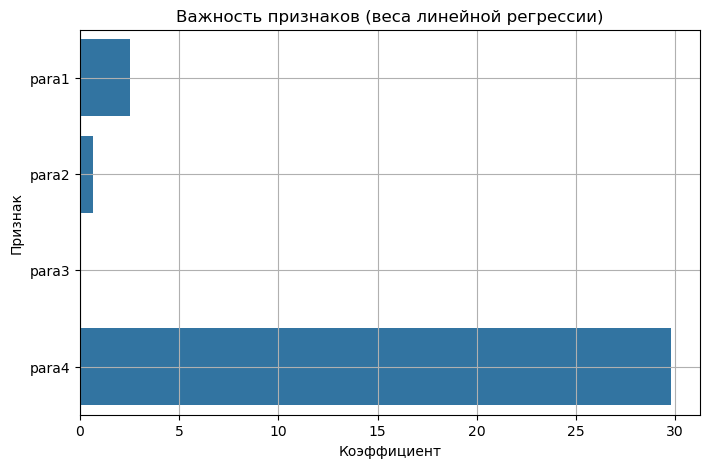

In [15]:
importance = model.coef_
feature_names = X.columns

plt.figure(figsize=(8, 5))
sns.barplot(x=importance, y=feature_names)
plt.title("Важность признаков (веса линейной регрессии)")
plt.xlabel("Коэффициент")
plt.ylabel("Признак")
plt.grid(True)
plt.show()